# Sentiment Analysis 

This notebook analyses the sentiment of the comments.

In [1]:
import numpy as np
import math

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from database.comments import Comments

import sys
sys.path.append('../functions')
from nlp_tasks import NLP_Tasks

import preprocessing_fncs as prep

/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Can use the sentiment analysis pipeline from HuggingFace

In [2]:
cs = Comments(env='dev')
nlp = NLP_Tasks()

Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


Device set to use mps:0
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


In [3]:
df = cs.read_all()
df = df.copy()
df = prep.format_df(df, borough_col_name='council')

In [4]:
df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score
0,86049,Barnet,21/2810/FUL_2,21/2810/FUL,"6 Tangmere Way London, United Kingdom NW9 5WW",Objects,2021-06-22,some residents in Gaydon lane have raised conc...,2025-04-10,51.599700,-0.248590,some residents in have raised concerns about t...,E09000003,-0.084598
1,78219,Barnet,24/3762/FUL_36,24/3762/FUL,88 Westbury Road London N12 7PD,Objects,2024-10-02,I am writing to express my strong objection to...,2025-04-08,51.612910,-0.189180,I am writing to express my strong objection to...,E09000003,-0.362558
2,86056,Barnet,21/2810/FUL_9,21/2810/FUL,1 Gaydon Lane Colindale London NW9 5WA,Objects,2021-06-20,"1. From the plans and elevations, the proposed...",2025-04-10,51.601675,-0.252985,"1. From the plans and elevations, the proposed...",E09000003,-0.424556
3,86065,Barnet,21/2810/FUL_18,21/2810/FUL,7 Elvington Lane London nw9 5wb,Objects,2021-06-08,we dont want this houses at the bottom of our ...,2025-04-10,51.602100,-0.252440,we dont want this houses at the bottom of our ...,E09000003,-0.365758
4,86321,Brent,22/1280_1,22/1280,"69 Crundale Avenue, London, NW9 9PJ",Neutral,2022-05-11,I am not objecting to this planning applicatio...,2025-04-10,51.584920,-0.276780,I am not objecting to this planning applicatio...,E09000005,0.019409


### Plot histograms of sentiment score 

In [5]:
# sns colour palette for stance 
stance_palette = {
    'Supports': '#426acf',  # blue
    'Objects': '#cf4242',   # orange
    'Neutral': '#b8cd73'    # green
}

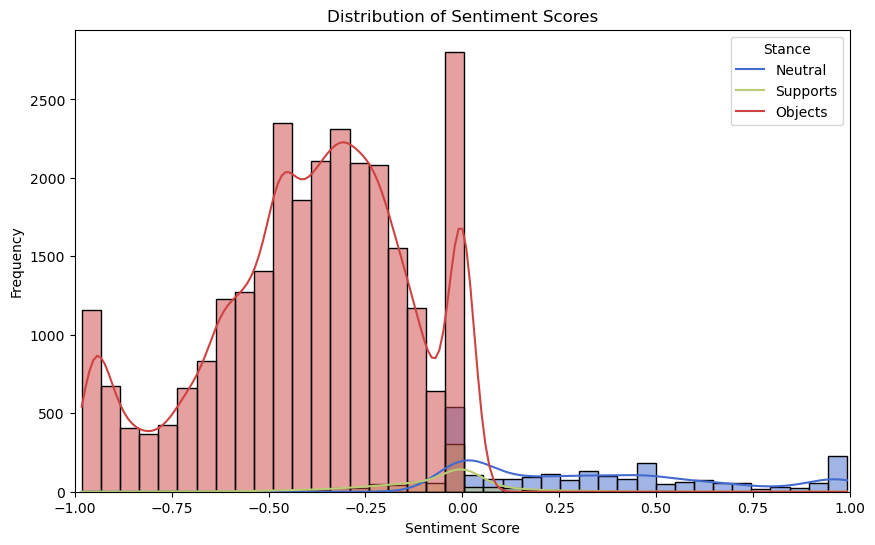

In [6]:
# Plot histogram of sentiment scores

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="sentiment_score", bins=40, kde=True, hue="stance", legend=True, palette=stance_palette)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.xlim(-1, 1)
plt.legend(title='Stance', loc='upper right', labels=['Neutral', 'Supports', 'Objects'])
# plt.axvline(x=0, color='red', linestyle='--', label='Neutral')
# plt.legend()
plt.show()

### Sentiment score by council 

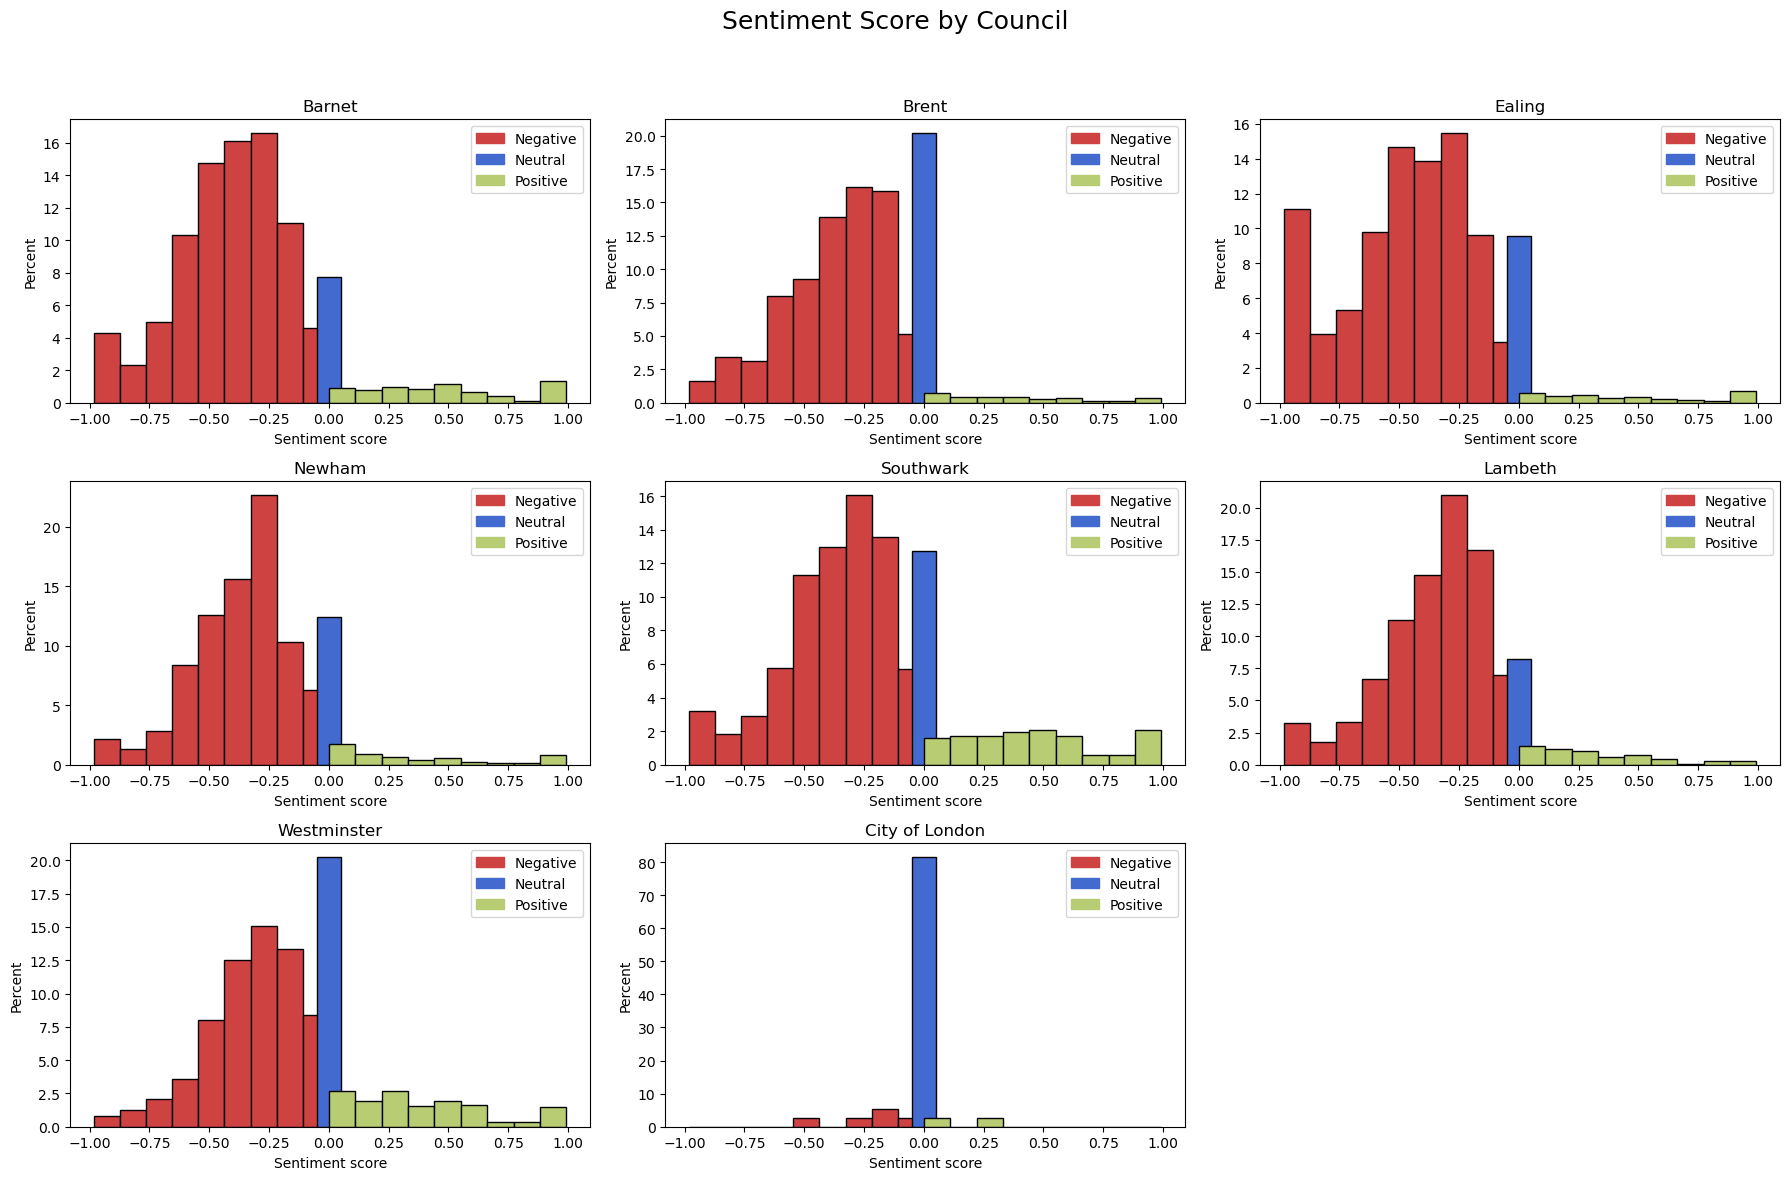

In [7]:
councils = df['council'].unique()

cols = 3
rows = math.ceil(len(councils) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*4))
axes = axes.flatten()

neg_bins = np.linspace(df['sentiment_score'].min(), -0.0001, 10)
pos_bins = np.linspace(0.0001, df['sentiment_score'].max(), 10)

for ax, council in zip(axes, councils):
    council_df = df[df['council'] == council]
    scores = council_df['sentiment_score'].dropna()
    total = len(scores)

    zeros = (scores == 0).sum()
    neg_scores = scores[scores < 0]
    pos_scores = scores[scores > 0]

    # Histogram for negative and positive values
    neg_counts, neg_edges = np.histogram(neg_scores, bins=neg_bins)
    pos_counts, pos_edges = np.histogram(pos_scores, bins=pos_bins)

    neg_perc = neg_counts / total * 100
    pos_perc = pos_counts / total * 100
    zero_perc = zeros / total * 100

    # Plot negative bins (red)
    ax.bar(neg_edges[:-1], neg_perc, width=np.diff(neg_edges), color="#cf4242", edgecolor='black', align='edge')

    # Plot zero bin (blue)
    if zero_perc > 0:
        ax.bar(0, zero_perc, width=0.1, color="#426acf", edgecolor='black', align='center')

    # Plot positive bins (green)
    ax.bar(pos_edges[:-1], pos_perc, width=np.diff(pos_edges), color="#b8cd73", edgecolor='black', align='edge')

    ax.set_title(council)
    ax.set_xlabel('Sentiment score')
    ax.set_ylabel('Percent')

    # Add a nice legend using Patch handles
    handles = [
        mpatches.Patch(color="#cf4242", label='Negative'),
        mpatches.Patch(color="#426acf", label='Neutral'),
        mpatches.Patch(color="#b8cd73", label='Positive')
    ]
    ax.legend(handles=handles, loc='upper right')

# Hide unused axes
for i in range(len(councils), len(axes)):
    fig.delaxes(axes[i])

fig.suptitle('Sentiment Score by Council', fontsize=18)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('../results/figures/sentiment_by_council.png', dpi=500)
plt.show()


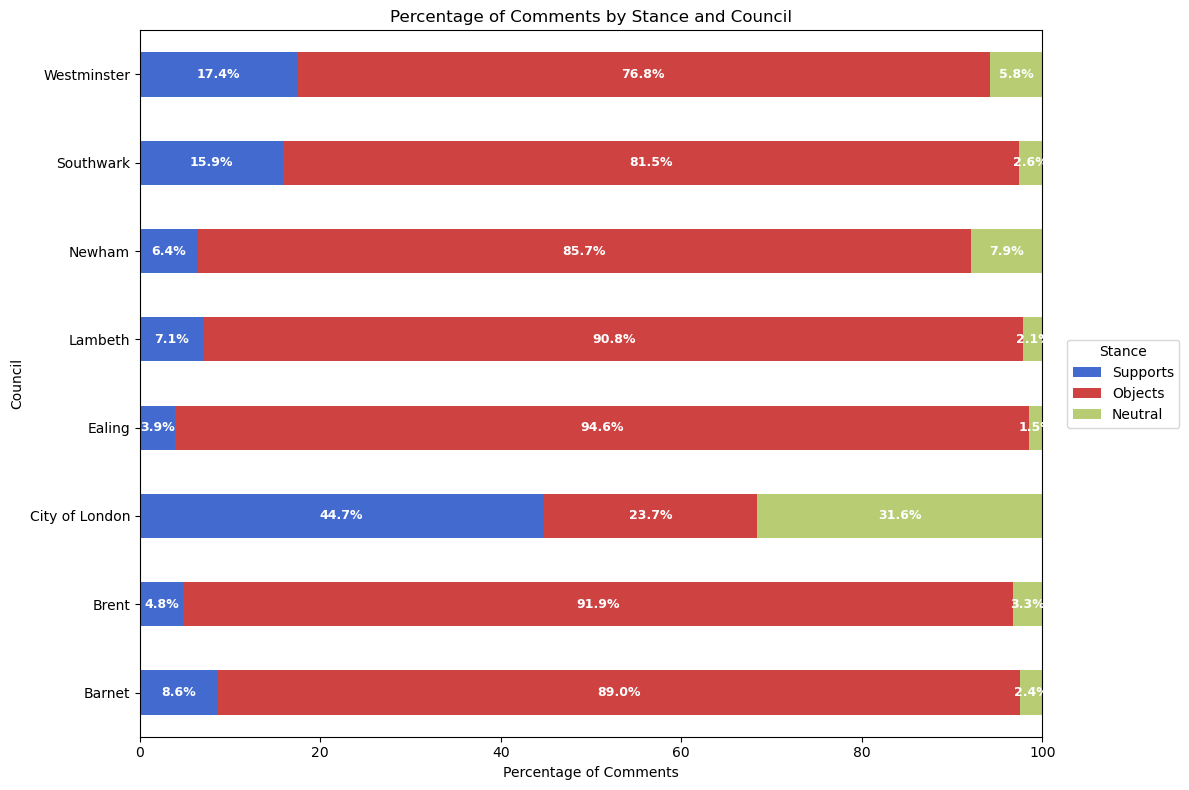

In [14]:
import matplotlib.pyplot as plt

# Count stance by council
stance_counts = df.groupby(['council', 'stance']).size().unstack(fill_value=0)
stance_counts = stance_counts[['Supports', 'Objects', 'Neutral']]  # consistent order

# Convert to percentages row-wise
stance_percent = stance_counts.div(stance_counts.sum(axis=1), axis=0) * 100

# Plot horizontal stacked bar
fig, ax = plt.subplots(figsize=(12, 8))
colors = [stance_palette['Supports'], stance_palette['Objects'], stance_palette['Neutral']]

stance_percent.plot(
    kind='barh',
    stacked=True,
    color=colors,
    ax=ax
)

# Add white text labels in the middle of each segment
for i, council in enumerate(stance_percent.index):
    left = 0  # starting position for first segment
    for stance in stance_percent.columns:
        value = stance_percent.loc[council, stance]
        if value > 0:
            ax.text(
                left + value / 2,          # x-position: middle of segment
                i,                         # y-position: row index
                f'{value:.1f}%',           # label text
                ha='center',
                va='center',
                color='white',
                fontsize=9, 
                fontweight='bold'
            )
        left += value  # move left to the start of next segment

# Labels, title
ax.set_xlabel('Percentage of Comments')
ax.set_ylabel('Council')
ax.set_title('Percentage of Comments by Stance and Council')

# Move legend outside the plot on the right
ax.legend(
    title='Stance',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    labels=['Supports', 'Objects', 'Neutral']
)

plt.xlim(0, 100)
plt.tight_layout()
plt.savefig('../results/figures/percent_comments_by_stance_and_council.png', dpi=500)
plt.show()
